# Mooring: Single Line using MoorLib 

In [ ]:
!git clone https://github.com/oriolcg/OE_SummerSchool_Notebooks.git

import os, sys

repo = "/content/OE_SummerSchool_Notebooks/2026"
os.chdir(repo)
sys.path.insert(0, repo)

!ls

In [1]:
import numpy as np
import pandas as pd
import math as math
from scipy import optimize
import matplotlib.pylab as plt
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline
# %matplotlib widget
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

In [2]:
# Constants

g=9.81

## Notebook Overview

This notebook revisits the single-line mooring problem using `MoorLib` instead of writing the catenary solver directly in the notebook.

Main ideas in this notebook:

1. Build a mooring line from multiple segments with different properties.
2. Solve the quasi-static equilibrium of the line for a prescribed fairlead position.
3. Inspect the resulting line shape and fairlead loads.
4. Generate a force-excursion curve by moving the fairlead.
5. Estimate line stiffness from the slope of the force response.

`MoorLib` supports:

- quasi-static catenary solutions
- lines composed of multiple segments
- 2D and 3D line objects
- fairlead force output in 3D for a given fairlead position

In [3]:
from MoorLib import moorSeg
from MoorLib import moorLine2D
from MoorLib import moorLine3D

`MoorLib` contains three main classes:

1. `moorSeg`: defines one line segment with its own length, weight, and axial stiffness
2. `moorLine2D`: builds and solves a mooring line in the vertical plane
3. `moorLine3D`: builds and solves a mooring line in 3D space

In this notebook we use `moorSeg` and `moorLine3D`.

## Create a segment

`moorSeg` is used to define one physical segment of the mooring line.

Each segment is described by:

- `L_seg`: segment length (m)
- `W_pm_seg`: weight per meter (N/m or equivalent submerged line weight input used by the library examples)
- `EA_seg`: axial stiffness (N)

Constructor:

- `moorSeg(L_seg, W_pm_seg, EA_seg)`

Below we define a mixed line with three segments: chain-polyester-chain. This lets us study how combining heavy and light segments changes force response and stiffness.

In [4]:
chainSeg1 = moorSeg(550.0, 376.0, 1725000000) 
polySeg1 = moorSeg(130.0, 10.9, 242000000)
chainSeg2 = moorSeg(20.0, 376.0, 1725000000)

## Create a line

`moorLine3D` creates a full mooring line in 3D.

To build a line you specify:

1. anchor position `(xAnch, yAnch, zAnch)`
2. ordered segment list `seg`, starting from the anchor end

Constructor:

- `moorLine3D(xAnch, yAnch, zAnch, seg=segArray)`

Even if the line lies in a vertical plane, using the 3D class gives direct access to `(F_x, F_y, F_z)` at the fairlead.

- We now create a line composed of a single chain segment, with the anchor placed at (0,0,0)

In [5]:
seg = [chainSeg1, polySeg1, chainSeg2]
iLine = moorLine3D(0.0, 0.0, 0.0, seg=seg)
pass

## Solve for the line: specify fairlead position

- The line object has now been created.
- We next prescribe the fairlead position and solve for the line equilibrium using

`moorLine3D.solveFl_xyz(xfl, yfl, zfl)`

This routine solves the quasi-static catenary problem for the full multi-segment line.

Inputs:

- `xfl`, `yfl`, `zfl`: fairlead coordinates in 3D

After solving, the object stores both the equilibrium state and the line geometry. Useful accessors are:

- `moorLine3D.xfl`, `moorLine3D.yfl`, `moorLine3D.zfl`
  - fairlead position used in the solve
- `moorLine3D.retLTot()`
  - total line length
- `moorLine3D.retLSusp()`
  - suspended line length
- `moorLine3D.retLBed()`
  - line length resting on the seabed
- `moorLine3D.retFlForce()`
  - fairlead force vector `(Fx, Fy, Fz)`
- `moorLine3D.plotLine3D(ds)`
  - returns coordinates for plotting the line shape
  - `ds` is the arc-length resolution used in the plot

This is the key step that connects geometry to mooring load response.

In [6]:
xfl = 660
yfl = 0.0
zfl = 121

iLine.solveFl_xyz( xfl, yfl, zfl )

print( iLine.xfl, iLine.yfl, iLine.zfl )

print('LTol', "%.2f"%iLine.retLTot(), 'LSusp', "%.2f"%iLine.retLSusp(),
                  'LBed', "%.2f"%iLine.retLBed(), 
                 ["%.2f kN"%(f/1000) for f in iLine.retFlForce()] )
pass

660 0.0 121
LTol 700.00 LSusp 224.18 LBed 475.82 ['-348.16 kN', '-0.00 kN', '-361.29 kN']


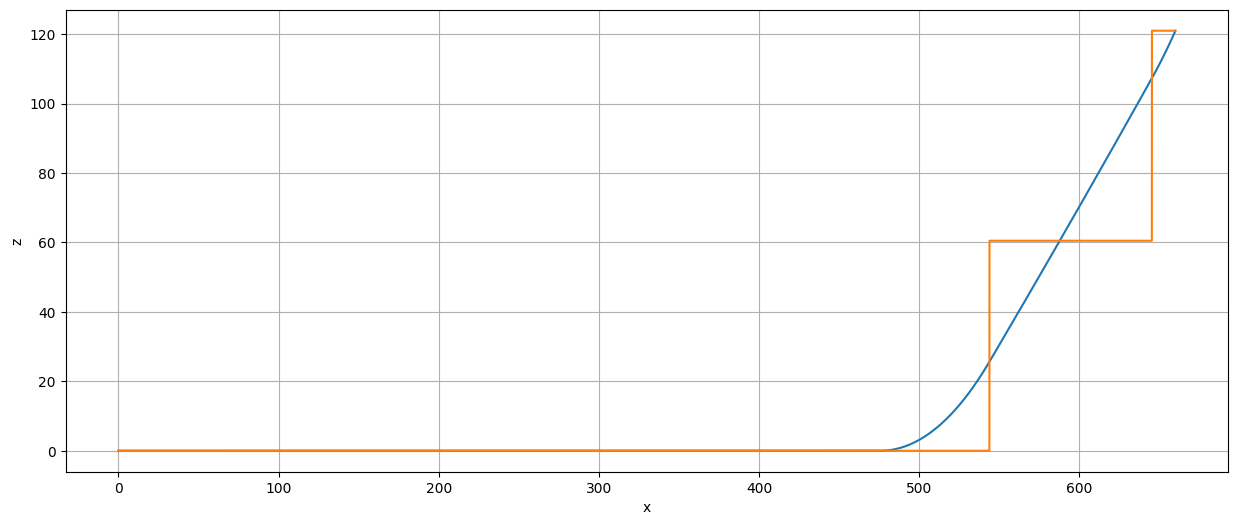

In [7]:
x,y,z,segTyp = iLine.plotLine3D(0.1)    
plt.figure()
plt.plot( x, z )
plt.plot( x, [iLine.zfl/2*iSeg for iSeg in segTyp]  )
plt.grid("on")
plt.xlabel('x')
plt.ylabel('z')
plt.show()
pass

### Auxiliary variables

We store selected quantities as **reference values** after solving one baseline equilibrium position.

Stored reference data:

- reference fairlead position: `(xflRef, yflRef, zflRef)`
- reference horizontal fairlead force: `HRef`
- reference seabed contact length: `LBedRef`

Methods used:

- `moorLine3D.setRef_FLxyz(xfl, yfl, zfl)`
- `moorLine3D.setRef_H(HRef)`
- `moorLine3D.setRef_LBed(LBed)`

Why this is useful:

- the reference fairlead position represents a known operating point or pretension state
- `HRef` and `LBedRef` provide good initial guesses for the nonlinear solver
- this makes repeated solves more robust when computing force-excursion curves

Reference values can be accessed using:

- `moorLine3D.xflRef`, `moorLine3D.yflRef`, `moorLine3D.zflRef`
- `moorLine3D.retRef_H()`
- `moorLine3D.retRef_LBed()`

In [8]:
iLine.setRef_FLxyz( iLine.xfl, iLine.yfl, iLine.zfl)
iLine.setRef_H( iLine.retFlForce_H() )
iLine.setRef_LBed(iLine.retLBed())

In [9]:
print(iLine.xflRef, iLine.yflRef, iLine.zflRef)
print(iLine.retRef_H())
print(iLine.retRef_LBed())

660 0.0 121
348156.81564202777
475.81962238823496


## Trial Run Around the Reference Position

We now perturb the fairlead position relative to the stored reference state.

This is a quick way to see how line shape, suspended length, seabed contact, and fairlead load change when the floater moves away from its baseline position.

685 0.0 121
LTol 700.00 LSusp 521.49 LBed 178.51 ['-3666.25 kN', '-0.00 kN', '-1457.93 kN']


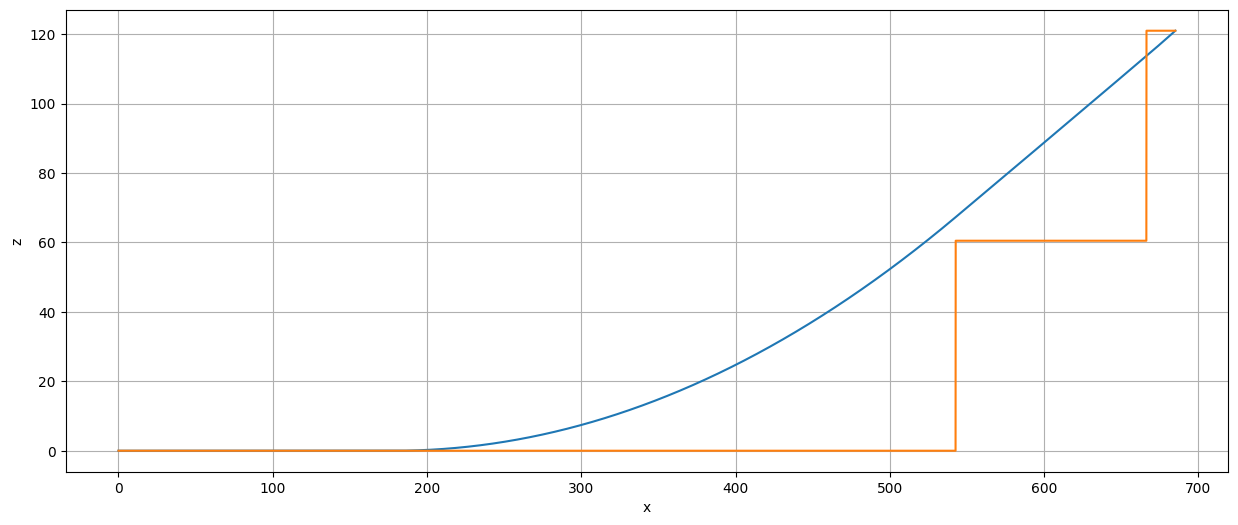

In [10]:
xfl = iLine.xflRef + 25
yfl = iLine.yflRef
zfl = iLine.zflRef
iLine.solveFl_xyz( xfl, yfl, zfl, HStart = iLine.retRef_H(), LBedStart = iLine.retRef_LBed() )

print( iLine.xfl, iLine.yfl, iLine.zfl )

print('LTol', "%.2f"%iLine.retLTot(), 'LSusp', "%.2f"%iLine.retLSusp(),
                  'LBed', "%.2f"%iLine.retLBed(), 
                 ["%.2f kN"%(f/1000) for f in iLine.retFlForce()] )
    
x,y,z,segTyp = iLine.plotLine3D(0.1)    
plt.figure()
plt.plot( x, z )
plt.plot( x, [iLine.zfl/2*iSeg for iSeg in segTyp]  )
plt.grid("on")
plt.xlabel('x')
plt.ylabel('z')
plt.show()
pass

## Force-Excursion Diagram

In this section we move the fairlead in the `x` direction while keeping `y` and `z` fixed at their reference values.

For each fairlead position, the notebook stores:

- suspended length `L_susp`
- force components `Fx`, `Fy`, `Fz`
- total tension magnitude

The resulting curves show how a mixed-segment line develops restoring force as excursion increases.

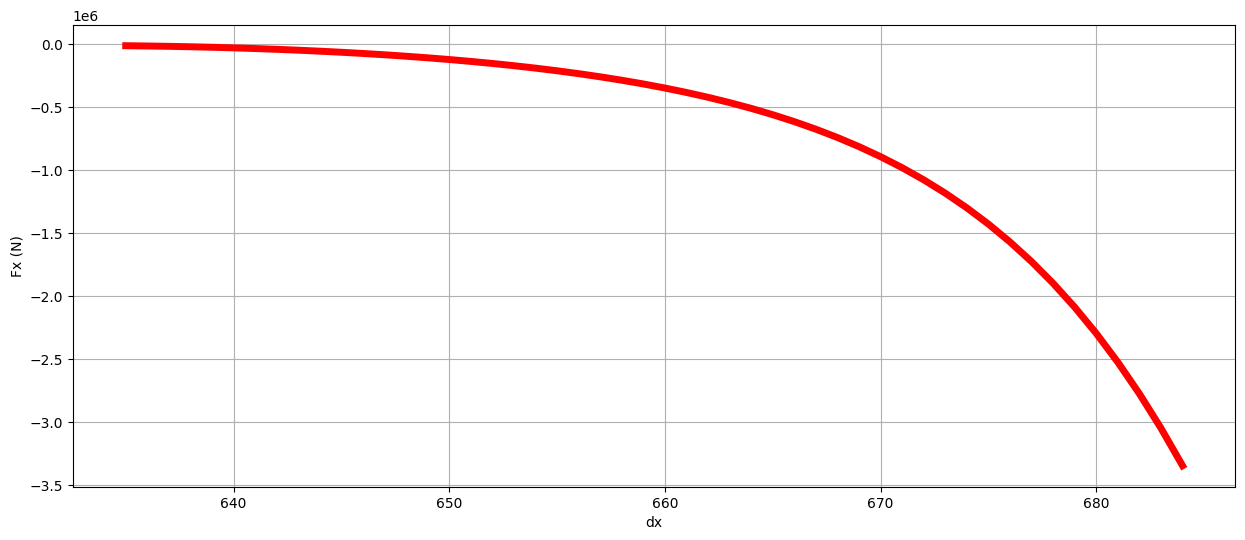

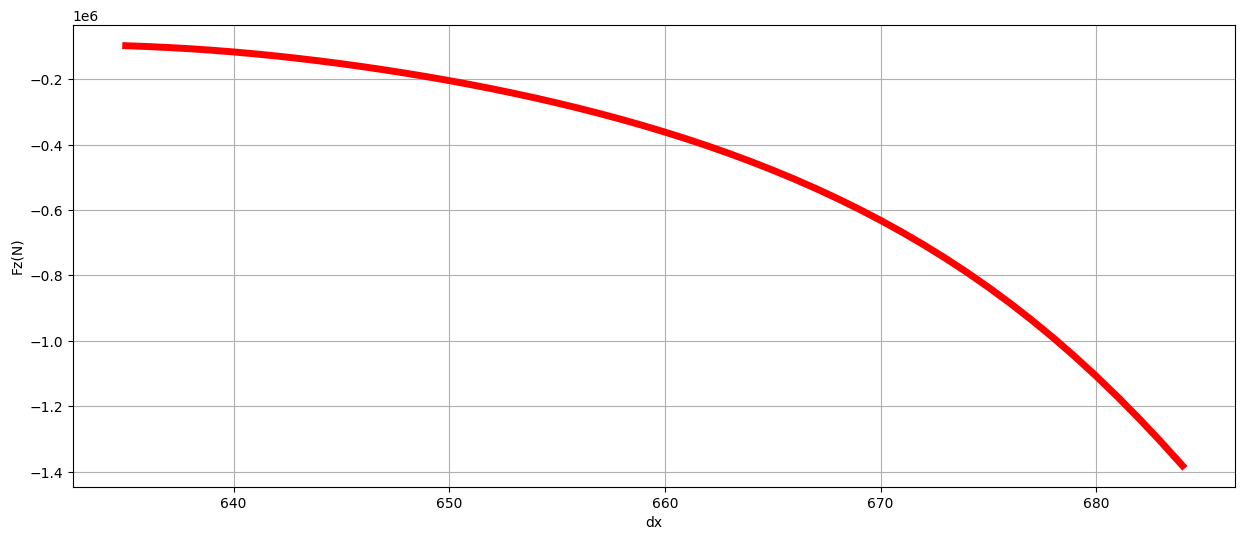

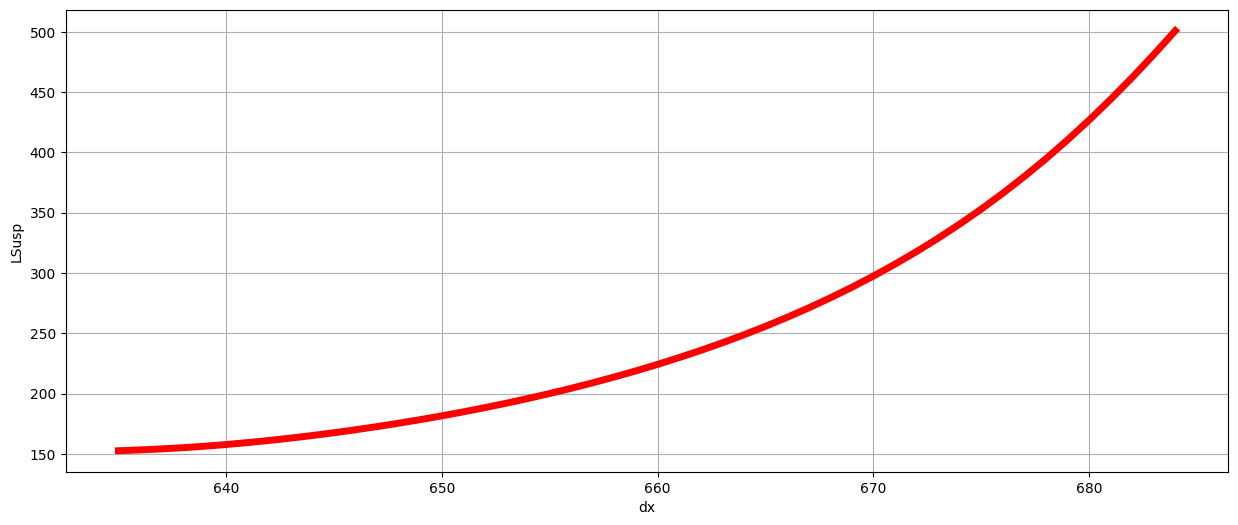

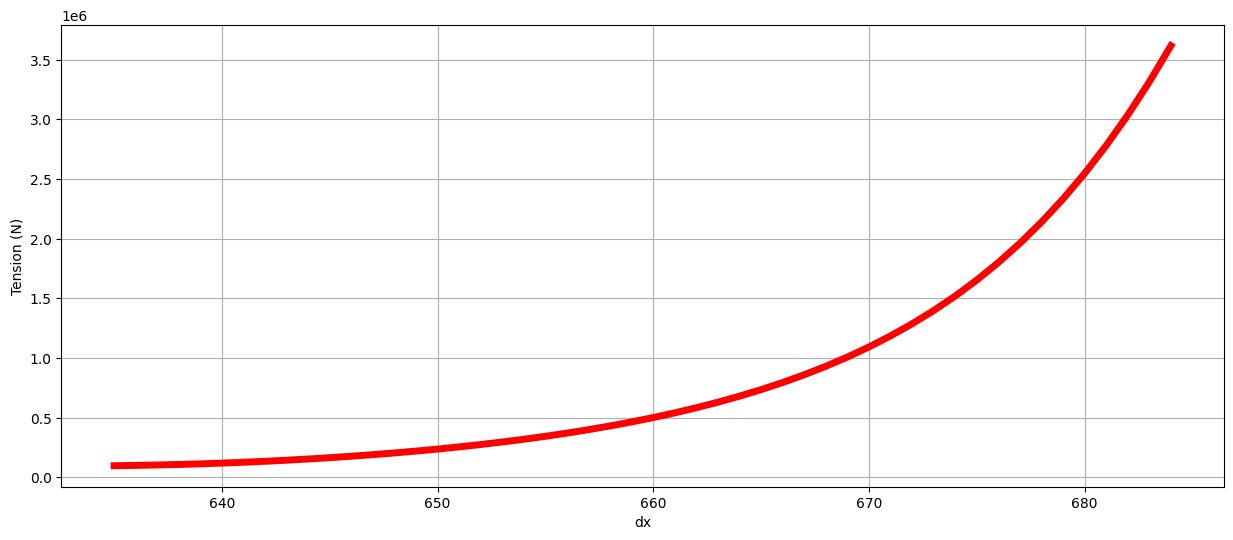

In [11]:
xfl = np.arange(iLine.xflRef-25, iLine.xflRef+25, 1)
yfl = iLine.yflRef
zfl = iLine.zflRef

lSuspMat=[]
FxMat=[]
FyMat=[]
FzMat=[]

for ixfl in xfl:
    iLine.solveFl_xyz( ixfl, yfl, zfl, HStart = iLine.retRef_H(), LBedStart = iLine.retRef_LBed() )
    lSuspMat.append(iLine.retLSusp())
    FxMat.append(iLine.retFlForce()[0])
    FyMat.append(iLine.retFlForce()[1])
    FzMat.append(iLine.retFlForce()[2])
    

TenMat = [ np.sqrt(ifx**2 + ify**2 + ifz**2) for (ifx,ify,ifz) in zip(FxMat,FyMat,FzMat) ]
    
plt.figure()
plt.plot( xfl, FxMat, 'r-', lw=5)
plt.grid("on")
plt.xlabel('dx')
plt.ylabel('Fx (N)')

plt.figure()
plt.plot( xfl, FzMat, 'r-', lw=5)
plt.grid("on")
plt.xlabel('dx')
plt.ylabel('Fz(N)')

plt.figure()
plt.plot( xfl, lSuspMat, 'r-', lw=5)
plt.grid("on")
plt.xlabel('dx')
plt.ylabel('LSusp')

plt.figure()
plt.plot( xfl, TenMat, 'r-', lw=5)
plt.grid("on")
plt.xlabel('dx')
plt.ylabel('Tension (N)')

plt.show()


pass

## Calculate Line Stiffness

We estimate stiffness from the slope of the force-excursion curves.

Using displacement in the `x` direction, the notebook computes:

- `kxx = dFx/dx`
- `kyx = dFy/dx`
- `kzx = dFz/dx`

The helper function below uses a central-difference approximation for interior points and copies neighboring values at the ends.

In [12]:
def calcStiffness(FMat,xMat):
    numPoi = len(FMat)
    kMat = FMat.copy()
    for i in range(1,numPoi-1):
        kMat[i] = (FMat[i+1] - FMat[i-1])/(xMat[i+1] - xMat[i-1])        
    
    kMat[0] = kMat[1]
    kMat[-1] = kMat[-2]
    
    return kMat

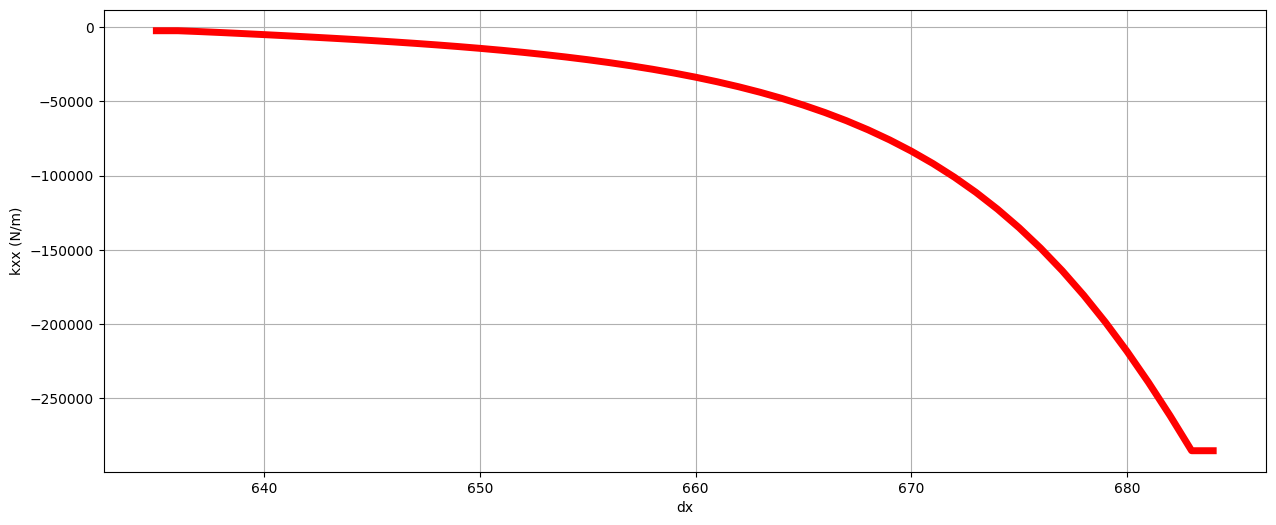

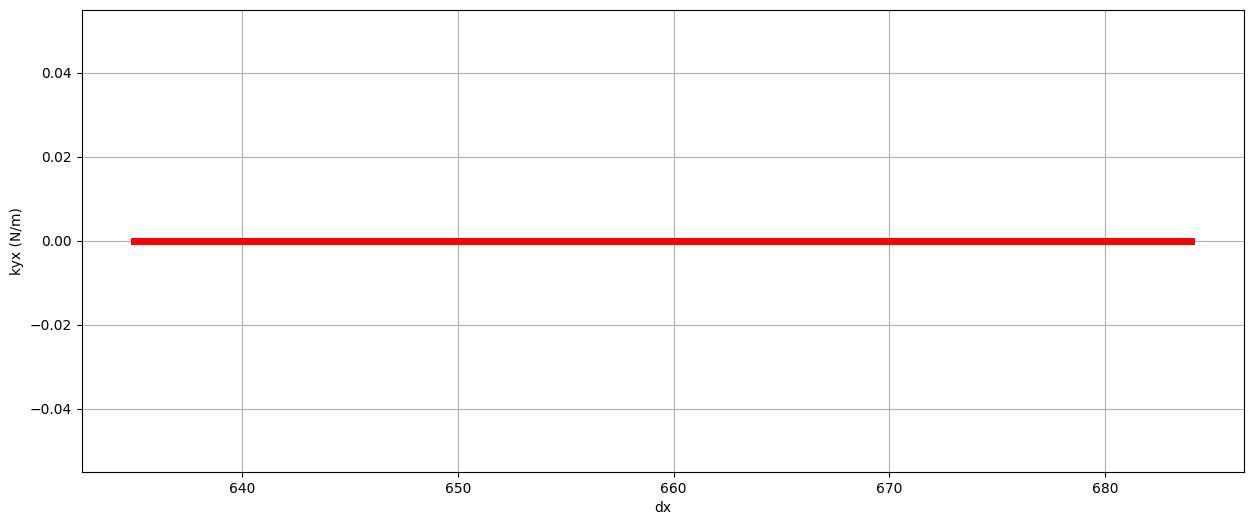

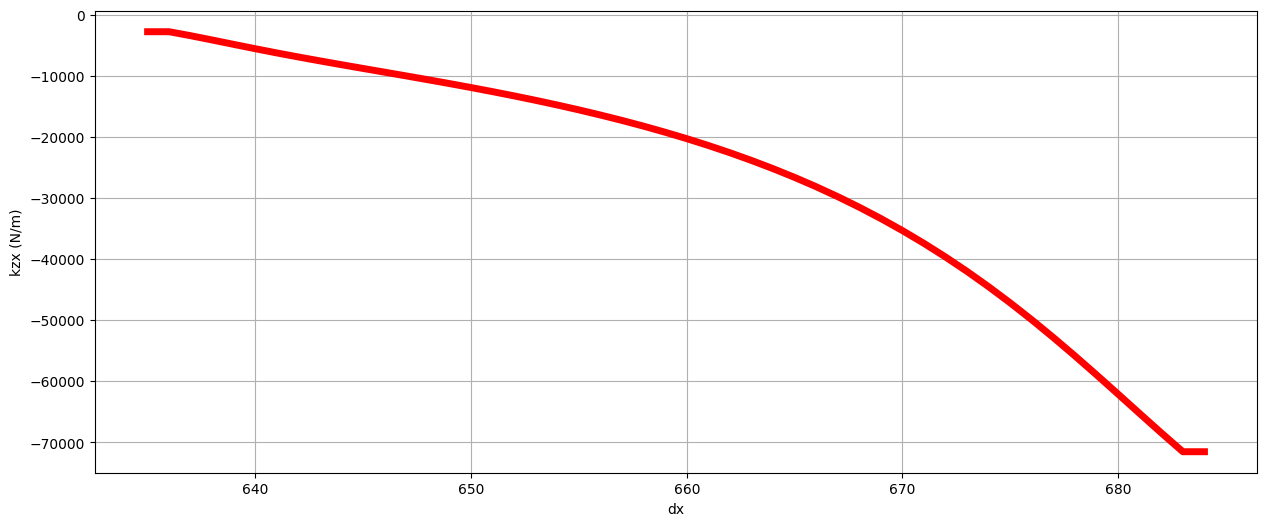

In [13]:

kxxMat = calcStiffness(FxMat, xfl)
kyxMat = calcStiffness(FyMat, xfl)
kzxMat = calcStiffness(FzMat, xfl)

plt.figure()
plt.plot( xfl, kxxMat, 'r-', lw=5)
plt.grid("on")
plt.xlabel('dx')
plt.ylabel('kxx (N/m)')


plt.figure()
plt.plot( xfl, kyxMat, 'r-', lw=5)
plt.grid("on")
plt.xlabel('dx')
plt.ylabel('kyx (N/m)')


plt.figure()
plt.plot( xfl, kzxMat, 'r-', lw=5)
plt.grid("on")
plt.xlabel('dx')
plt.ylabel('kzx (N/m)')

plt.show()

pass

## Student Exercise: Vary Segment Properties

Use the next cell to explore how changing segment properties affects line response.

### Tasks

1. Change one segment property at a time: length, weight per meter, or axial stiffness.
2. Compare the updated force-excursion plots for `Fx`, `Fz`, suspended length, and total tension.
3. Compare the stiffness curves `kxx` and `kzx`.
4. Identify which segment has the strongest influence on restoring force in your chosen excursion range.

### Suggested cases

- Increase polyester segment length
- Reduce polyester axial stiffness
- Increase chain weight per meter
- Replace one chain segment with a lighter segment

Write a short conclusion explaining how segment distribution changes seabed contact, suspended length, and stiffness.

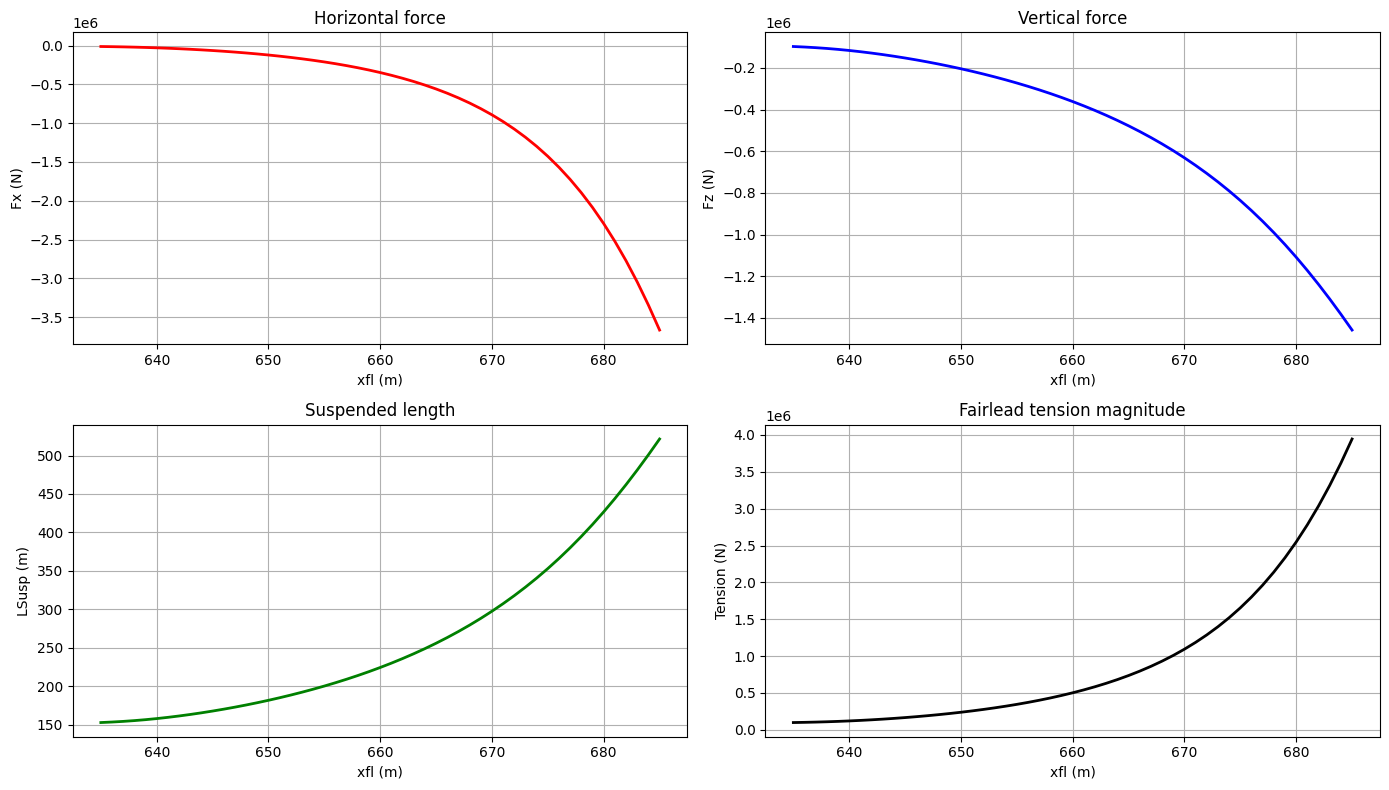

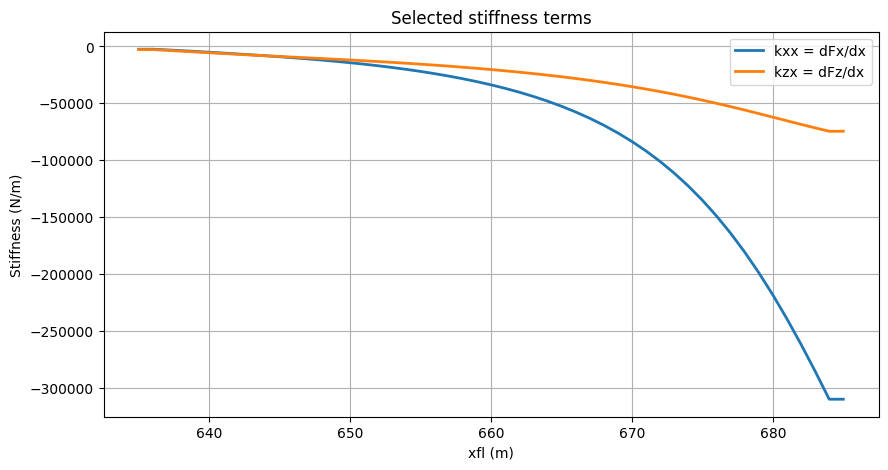

Reference force (kN): [-3666.253, -0.0, -1457.933]
Reference lengths (m): LTot = 700.0 LSusp = 521.49 LBed = 178.51


In [14]:
# --- Exercise template: edit segment properties and rerun ---

# Rebuild segments (change one parameter at a time)
chainSeg1 = moorSeg(550.0, 376.0, 1725000000)
polySeg1 = moorSeg(130.0, 10.9, 242000000)
chainSeg2 = moorSeg(20.0, 376.0, 1725000000)

# Build mixed line
seg = [chainSeg1, polySeg1, chainSeg2]
iLine = moorLine3D(0.0, 0.0, 0.0, seg=seg)

# Choose baseline fairlead position and solve
xfl0 = 660
yfl0 = 0.0
zfl0 = 121
iLine.solveFl_xyz(xfl0, yfl0, zfl0)

# Store reference state for repeated solves
iLine.setRef_FLxyz(iLine.xfl, iLine.yfl, iLine.zfl)
iLine.setRef_H(iLine.retFlForce_H())
iLine.setRef_LBed(iLine.retLBed())

# Excursion sweep around the reference position
xfl_array = np.arange(iLine.xflRef - 25, iLine.xflRef + 26, 1)
yfl = iLine.yflRef
zfl = iLine.zflRef

lSuspMat = []
FxMat = []
FyMat = []
FzMat = []

for ixfl in xfl_array:
    iLine.solveFl_xyz(
        ixfl, yfl, zfl, HStart=iLine.retRef_H(), LBedStart=iLine.retRef_LBed()
    )
    lSuspMat.append(iLine.retLSusp())
    FxMat.append(iLine.retFlForce()[0])
    FyMat.append(iLine.retFlForce()[1])
    FzMat.append(iLine.retFlForce()[2])

TenMat = [np.sqrt(ifx**2 + ify**2 + ifz**2) for (ifx, ify, ifz) in zip(FxMat, FyMat, FzMat)]

# Force and length plots
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
ax[0, 0].plot(xfl_array, FxMat, 'r-', lw=2)
ax[0, 0].grid(True)
ax[0, 0].set_xlabel('xfl (m)')
ax[0, 0].set_ylabel('Fx (N)')
ax[0, 0].set_title('Horizontal force')

ax[0, 1].plot(xfl_array, FzMat, 'b-', lw=2)
ax[0, 1].grid(True)
ax[0, 1].set_xlabel('xfl (m)')
ax[0, 1].set_ylabel('Fz (N)')
ax[0, 1].set_title('Vertical force')

ax[1, 0].plot(xfl_array, lSuspMat, 'g-', lw=2)
ax[1, 0].grid(True)
ax[1, 0].set_xlabel('xfl (m)')
ax[1, 0].set_ylabel('LSusp (m)')
ax[1, 0].set_title('Suspended length')

ax[1, 1].plot(xfl_array, TenMat, 'k-', lw=2)
ax[1, 1].grid(True)
ax[1, 1].set_xlabel('xfl (m)')
ax[1, 1].set_ylabel('Tension (N)')
ax[1, 1].set_title('Fairlead tension magnitude')

plt.tight_layout()
plt.show()

# Stiffness curves
kxxMat = calcStiffness(FxMat, xfl_array)
kyxMat = calcStiffness(FyMat, xfl_array)
kzxMat = calcStiffness(FzMat, xfl_array)

plt.figure(figsize=(10, 5))
plt.plot(xfl_array, kxxMat, label='kxx = dFx/dx', lw=2)
plt.plot(xfl_array, kzxMat, label='kzx = dFz/dx', lw=2)
plt.grid(True)
plt.xlabel('xfl (m)')
plt.ylabel('Stiffness (N/m)')
plt.title('Selected stiffness terms')
plt.legend()
plt.show()

print('Reference force (kN):', [round(f / 1000, 3) for f in iLine.retFlForce()])
print('Reference lengths (m):', 'LTot =', round(iLine.retLTot(), 2), 'LSusp =', round(iLine.retLSusp(), 2), 'LBed =', round(iLine.retLBed(), 2))